# NB-03 — Extracción de Embeddings (FASE 0) — CORREGIDO v9
**Semana 10** — Backbone ViT-Tiny congelado → CLS tokens → guardar `.npy`

### Correcciones aplicadas vs v6
| # | Problema | Corrección |
|---|----------|------------|
| **20** | **`preparar_para_vit` 3D: si D < n_slices, el shape variaba entre batches → reshape en `extract_embeddings` fallaba** | **Padding con replicación del último slice: salida siempre `[B*n_slices, C, H, W]`** |
| **21** | **`extract_embeddings` reshape 3D usaba la variable `n` local (podía ser < n_slices) → índices erróneos en mean pooling** | **Reshape usa `n_slices` fijo (garantizado por FIX-20)** |
| **22** | **Sin generación del test set held-out → ablation no podía hacer evaluación final** | **Nueva celda 13b: genera `all_test_Z.npy` y `all_test_expert_y.npy`** |
| **23** | **`LUNANpyDataset` usaba `pd.read_csv` sin importar `pandas` en la celda** | **`import pandas as pd` añadido explícitamente en la celda del dataset** |
| **25** | **Páncreas cargaba embeddings precomputados (`panc_train_Z.npy`) → silhouette = 0.85 irreal, ablation no publicable** | **`PancDataset` extrae embeddings con ViT-Tiny igual que los otros 4 datasets** |
| **28** | **`PancDataset.__getitem__` llama nibabel por cada muestra (~1-5s/vol) con `num_workers=0` → >5 min por epoch** | **Nueva celda de pre-cache: `.nii.gz→.npy` una sola vez; `__getitem__` usa `np.load` (<5 ms). H/W resize a 224 directo.** |
| **27** | **`PancDataset.__getitem__` no estandarizaba H×W → `default_collate` fallaba con volúmenes 512×512 y 1024×1024** | **Resize bilineal a `H_FIXED=W_FIXED=512` en `__getitem__` antes del `return`; dummy también usa atributos de clase** |
| **26** | **`preparar_para_vit` no rescalaba a [0,1] antes de ImageNet normalize → Páncreas (z-score) producía valores fuera de rango** | **Rescale per-slice min-max a [0,1] añadido en la rama 3D antes del normalize** |


In [1]:
# ── Imports ──────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import random
import timm
import os
from pathlib import Path
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast          # ← API moderna (no torch.cuda.amp)
from PIL import Image
from sklearn.model_selection import train_test_split

# ── Reproducibilidad ─────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Hardware ─────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64      # reducir a 32 si hay OOM en GPU

# ── Directorios de salida ─────────────────────────────────────────
Path('embeddings').mkdir(exist_ok=True)
Path('figures').mkdir(exist_ok=True)

print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')
print(f'timm     : {timm.__version__}')


c:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device   : cuda
PyTorch  : 2.5.1+cu121
timm     : 1.0.26


## 1. Rutas de datos

In [2]:
import os

# ── Raíz de datos ────────────────────────────────────────────────
BASE_PATH = r"C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\training\EMBEDDINGS\data"

DATASETS = {
    "chest" : os.path.join(BASE_PATH, "chest"),
    "isic"  : os.path.join(BASE_PATH, "isic", "archive"),
    "osteo" : os.path.join(BASE_PATH, "osteo"),
    "luna"  : os.path.join(BASE_PATH, "luna"),
    "panc"  : os.path.join(BASE_PATH, "panc"),
}

# ── Paths individuales ───────────────────────────────────────────
path_chest = DATASETS['chest']
path_isic  = DATASETS['isic']
path_osteo = DATASETS['osteo']
path_luna  = DATASETS['luna']
path_panc  = DATASETS['panc']

# ── CHEST (robusto, sin archive) ────────────────────────────────
CHEST_BASE = os.path.join(path_chest, "cxr14_cache_v21_384")

# 🔥 detectar múltiples carpetas reales
CHEST_IMAGE_DIRS = []
if os.path.exists(CHEST_BASE):
    for d in os.listdir(CHEST_BASE):
        full_path = os.path.join(CHEST_BASE, d, "images")
        if d.startswith("images_") and os.path.exists(full_path):
            CHEST_IMAGE_DIRS.append(full_path)

# 🔥 splits (tu estructura se mantiene)
CHEST_SPLITS = os.path.join(path_chest, "splits")
os.makedirs(CHEST_SPLITS, exist_ok=True)

# ── ISIC ─────────────────────────────────────────────────────────
ISIC_IMAGES = os.path.join(path_isic, "ISIC_2019_Training_Input_preprocessed")
ISIC_CSV    = os.path.join(path_isic, "ISIC_2019_Training_GroundTruth.csv")

# ── OSTEO ────────────────────────────────────────────────────────
OSTEO_SPLITS = os.path.join(path_osteo, "oa_splits")
OSTEO_TRAIN  = os.path.join(OSTEO_SPLITS, "train")
OSTEO_VAL    = os.path.join(OSTEO_SPLITS, "val")
OSTEO_TEST   = os.path.join(OSTEO_SPLITS, "test")

# ── LUNA ─────────────────────────────────────────────────────────
LUNA_PATH = os.path.join(path_luna, "archive (2)")

# ── Páncreas ─────────────────────────────────────────────────────
# [FIX-25] Eliminadas PANC_TRAIN_Z / PANC_TRAIN_Y / PANC_VAL_Z / PANC_VAL_Y.
# Páncreas se extrae igual que LUNA16: PancDataset → ViT → panc_{split}_Z.npy
#
# Los volúmenes CT crudos están en los directorios batch_* como .nii / .nii.gz.
# PancDataset los lee con nibabel, aplica HU clip [-150, +250] → [0, 1] y
# devuelve tensores (1, D, H, W). preparar_para_vit toma los slices centrales
# y aplica Normalize ImageNet, idéntico al pipeline de LUNA16.

PANC_RAW_ROOT = r"C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\data"

PANC_BATCH_DIRS = [
    os.path.join(PANC_RAW_ROOT, "batch_1"),
    os.path.join(PANC_RAW_ROOT, "batch_2"),
    os.path.join(PANC_RAW_ROOT, "batch_3"),
]
PANC_BATCH_DIRS = [p for p in PANC_BATCH_DIRS if os.path.exists(p)]
print(f"Páncreas batch dirs detectados: {len(PANC_BATCH_DIRS)}")
for _bd in PANC_BATCH_DIRS:
    _n = sum(1 for _r, _, _fs in os.walk(_bd)
             for _f in _fs if _f.endswith(('.nii', '.nii.gz')))
    print(f"  {_bd}  →  {_n} volúmenes")

# ────────────────────────────────────────────────────────────────
# 🔍 VERIFICACIONES
# ────────────────────────────────────────────────────────────────

print("\n═══════════════════════════════════════")
print("VERIFICACIÓN DATASETS")
print("═══════════════════════════════════════")

for name, path in DATASETS.items():
    print(f"{'[OK]' if os.path.exists(path) else '[MISSING]'} {name}: {path}")

# ── Chest ────────────────────────────────────────────────────────
print("\nChest:")

print(f"  base     : {'OK' if os.path.exists(CHEST_BASE) else 'MISSING'}")
print(f"  splits   : {'OK' if os.path.exists(CHEST_SPLITS) else 'MISSING'}")
print(f"  n_folders: {len(CHEST_IMAGE_DIRS)}")

# 🔥 conteo robusto de imágenes
total_imgs = 0
for d in CHEST_IMAGE_DIRS:
    try:
        total_imgs += sum(1 for f in os.listdir(d) if f.lower().endswith('.jpg'))
    except Exception:
        print(f"  ⚠ error leyendo: {d}")

print(f"  imágenes : {total_imgs:,}")

# ── ISIC ─────────────────────────────────────────────────────────
print("\nISIC:")
print(f"  images : {'OK' if os.path.exists(ISIC_IMAGES) else 'MISSING'}")
print(f"  csv    : {'OK' if os.path.exists(ISIC_CSV) else 'MISSING'}")

# ── OSTEO ────────────────────────────────────────────────────────
print("\nOSTEO:")
print(f"  train : {'OK' if os.path.exists(OSTEO_TRAIN) else 'MISSING'}")
print(f"  val   : {'OK' if os.path.exists(OSTEO_VAL) else 'MISSING'}")
print(f"  test  : {'OK' if os.path.exists(OSTEO_TEST) else 'MISSING'}")

if os.path.exists(OSTEO_SPLITS):
    print("\n  contenido oa_splits:")
    print(" ", os.listdir(OSTEO_SPLITS))

# ── LUNA ─────────────────────────────────────────────────────────
print("\nLUNA:")
if os.path.exists(LUNA_PATH):
    print("  OK:", LUNA_PATH)
    print("  ejemplo:", os.listdir(LUNA_PATH)[:5])
else:
    print("  MISSING:", LUNA_PATH)

# ── Páncreas ─────────────────────────────────────────────────────
print("\nPÁNCREAS (raw CT volumes):")
_panc_npys = list(__import__('pathlib').Path(path_panc).rglob('*.npy')) if os.path.exists(path_panc) else []
print(f"  {'[OK]' if os.path.exists(path_panc) else '[MISSING]'} {path_panc}")
print(f"  {len(_panc_npys):,} archivos .npy encontrados")

Páncreas batch dirs detectados: 3
  C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\data\batch_1  →  557 volúmenes
  C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\data\batch_2  →  566 volúmenes
  C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\data\batch_3  →  580 volúmenes

═══════════════════════════════════════
VERIFICACIÓN DATASETS
═══════════════════════════════════════
[OK] chest: C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\training\EMBEDDINGS\data\chest
[OK] isic: C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\training\EMBEDDINGS\data\isic\archive
[OK] osteo: C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de da

## 2. Exploración de estructura de datasets

In [3]:
def explorar_dataset(path, nombre, max_files=25):
    """Muestra la estructura de archivos del dataset."""
    p = Path(path)
    if not p.exists():
        print(f'[{nombre}] ❌ Ruta no existe: {path}')
        return
    print(f'\n{"─"*60}')
    print(f'  {nombre}  →  {path}')
    print(f'{"─"*60}')
    archivos = sorted(p.rglob('*'))
    for a in archivos[:max_files]:
        rel  = a.relative_to(p)
        tipo = 'F' if a.is_file() else 'D'
        size = f'{a.stat().st_size / 1024:.1f} KB' if a.is_file() else ''
        print(f'  {tipo}  {rel}  {size}')
    total = len(archivos)
    if total > max_files:
        print(f'  ... ({total} entradas en total)')

for name, path in DATASETS.items():
    explorar_dataset(path, name)



────────────────────────────────────────────────────────────
  chest  →  C:\Users\Acer\OneDrive\Escritorio\CARPETAS\septimo semestre\Analitica de datos\Deep learnig avanzado\PRIMER PROYECTO\training\EMBEDDINGS\data\chest
────────────────────────────────────────────────────────────
  D  cxr14_cache_v21_384  
  D  cxr14_cache_v21_384\images_001  
  D  cxr14_cache_v21_384\images_001\images  
  F  cxr14_cache_v21_384\images_001\images\00000001_000_cache384.jpg  34.0 KB
  F  cxr14_cache_v21_384\images_001\images\00000001_001_cache384.jpg  32.8 KB
  F  cxr14_cache_v21_384\images_001\images\00000001_002_cache384.jpg  28.1 KB
  F  cxr14_cache_v21_384\images_001\images\00000002_000_cache384.jpg  33.1 KB
  F  cxr14_cache_v21_384\images_001\images\00000003_000_cache384.jpg  32.9 KB
  F  cxr14_cache_v21_384\images_001\images\00000003_001_cache384.jpg  31.2 KB
  F  cxr14_cache_v21_384\images_001\images\00000003_002_cache384.jpg  29.6 KB
  F  cxr14_cache_v21_384\images_001\images\00000003_003_cache

## 3. Transformaciones mínimas para cargar imágenes preprocesadas

> Los datos ya están preprocesados offline (CLAHE, resize 224×224, HU clipping para LUNA16).
> Aquí **solo** se aplica `ToTensor()` + normalización ImageNet, que el backbone ViT-Tiny
> requiere independientemente del preprocesado médico previo.
> **No** se aplica resize (redundante), CLAHE, ni augmentations.

In [4]:
# ── Transformación 2D — [FIX-18] Resize obligatorio ─────────────────────────
#
# ROOT CAUSE del fallo silencioso de ISIC:
#   Las imágenes ISIC en disco tienen tamaños mixtos (ej. 223x298, 224x224…).
#   Sin Resize, cada imagen produce un tensor de distinto shape.
#   default_collate no puede apilarlos → RuntimeError: stack expects equal size.
#   extraer_y_guardar capturaba ese error y hacía raise → cell 27 continuaba
#   sin añadir 'isic' a results → _unpack fallaba porque tampoco había .npy.
#
# Resize(224,224) garantiza shape uniforme en todos los datasets 2D.
# También acelera Chest (1024x1024→224x224) y Osteo (640x640→224x224):
#   tensores 9x/8x más pequeños → menos RAM y tráfico PCIe.

transform_2d = transforms.Compose([
    transforms.Resize((224, 224)),               # [FIX-18] obligatorio: shape uniforme
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# LUNA16: patches .npy cargados como numpy; normalización en preparar_para_vit.
print('Transformaciones definidas:')
print('  2D  → Resize(224,224) + ToTensor + Normalize(ImageNet)')
print('  3D  → numpy float32; normalización ImageNet en preparar_para_vit')


Transformaciones definidas:
  2D  → Resize(224,224) + ToTensor + Normalize(ImageNet)
  3D  → numpy float32; normalización ImageNet en preparar_para_vit


## 4. Clases de Dataset personalizadas

### 4A. NIH ChestX-ray14 — multilabel con split files
Estructura esperada:
```
chest/
  images_001/ ... images_012/   ← todas las imágenes (búsqueda recursiva)
  nih_train_list.txt            ← nombres de archivo, uno por línea
  nih_val_list.txt
  Data_Entry_2017.csv           ← columnas: 'Image Index', 'Finding Labels'
```


In [5]:
# ── [FIX-17] NIHChestDataset CORREGIDO (6 clases + robusto) ─────────────────

class NIHChestDataset(Dataset):
    """
    ChestX-ray14 multilabel dataset (versión robusta).

    ✔ Soporta múltiples carpetas images_001...images_012
    ✔ Usa splits (flexible: splits o archive/splits)
    ✔ CSV opcional
    ✔ 6 clases específicas del proyecto
    ✔ Manejo de imágenes corruptas
    """

    CLASSES = [
        'Infiltration',
        'Effusion',
        'Atelectasis',
        'Nodule',
        'Mass',
        'Pneumothorax'
    ]
    CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

    def __init__(self, root, split_file, transform=None):
        self.transform = transform
        root = Path(root)

        # ── 1. Índice global de imágenes ─────────────────────────
        self.img_index = {}

        base = root / "cxr14_cache_v21_384"
        if not base.exists():
            raise FileNotFoundError(f"No existe: {base}")

        for d in os.listdir(base):
            if d.startswith("images_"):
                img_dir = base / d / "images"
                if img_dir.exists():
                    for p in img_dir.glob("*.jpg"):
                        self.img_index[p.name] = p

        print(f'  [Chest] Índice: {len(self.img_index):,} imágenes en disco')

        # ── 2. Leer split (🔥 CORREGIDO: flexible) ────────────────
        possible_paths = [
            root / "splits" / split_file,
            root / "archive" / "splits" / split_file,
            root / split_file,
            Path(split_file)
        ]

        split_path = None
        for p in possible_paths:
            if p.exists():
                split_path = p
                break

        if split_path is None:
            raise FileNotFoundError(
                f'Split file no encontrado: {split_file}\n'
                f'Buscado en: {possible_paths}'
            )

        with open(split_path) as f:
            filenames = [l.strip() for l in f if l.strip()]

        print(f'  [Chest] Split "{split_file}": {len(filenames):,} entradas')

        # ── 3. Labels (CSV opcional) ───────────────────────────────
        csv_path = root / "Data_Entry_2017.csv"

        self.use_labels = False
        if csv_path.exists():
            df = pd.read_csv(csv_path, usecols=['Image Index', 'Finding Labels'])
            self.label_map = dict(zip(df['Image Index'], df['Finding Labels']))
            self.use_labels = True
            print("  [Chest] Labels reales activados (6 clases)")
        else:
            print("  [Chest] ⚠ Sin CSV → labels dummy (solo pipeline)")

        # ── 4. Construir samples ──────────────────────────────────
        self.samples = []
        missing = 0
        skipped_empty = 0

        for fname in filenames:
            if fname not in self.img_index:
                missing += 1
                continue

            if self.use_labels:
                findings = self.label_map.get(fname, "No Finding").split("|")

                multi_hot = np.zeros(len(self.CLASSES), dtype=np.float32)

                for fnd in findings:
                    fnd = fnd.strip()
                    if fnd in self.CLASS2IDX:
                        multi_hot[self.CLASS2IDX[fnd]] = 1.0

                # 🔥 FILTRO CLAVE
                if multi_hot.sum() == 0:
                    skipped_empty += 1
                    continue
            else:
                multi_hot = np.zeros(len(self.CLASSES), dtype=np.float32)

            self.samples.append((self.img_index[fname], multi_hot))

        if missing > 0:
            print(f'  [Chest] ⚠ {missing} imágenes del split no encontradas')

        if skipped_empty > 0:
            print(f'  [Chest] ⚠ {skipped_empty} muestras sin clases (filtradas)')

        print(f'  [Chest] Dataset listo: {len(self.samples):,} muestras')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, multi_hot = self.samples[idx]

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            print(f'  [Chest] ⚠ imagen corrupta idx={idx}: {img_path.name}')
            img       = Image.new('RGB', (224, 224), color=0)
            multi_hot = np.full(len(self.CLASSES), -1, dtype=np.float32)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(multi_hot, dtype=torch.float32)


print('✓ NIHChestDataset corregido (6 clases, robusto y alineado al MoE)')

✓ NIHChestDataset corregido (6 clases, robusto y alineado al MoE)


### 4B. ISIC 2019 — clasificación 9 clases con split files
Estructura esperada:
```
isic/
  ISIC_2019_Training_Input_preprocessed/   ← imágenes ISIC_XXXXXXX.jpg/.png
  ISIC_2019_Training_GroundTruth/
    ISIC_2019_Training_GroundTruth.csv     ← cols: image, MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK
  isic_train.txt / isic_val.txt            ← IDs de imagen, uno por línea
```


In [6]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import pandas as pd

# ── [FIX-15] ISICDataset: aplica split real ('train'/'val') ──────────────────
# BUG original: el parámetro split se recibía pero nunca se usaba →
#   ds_isic_train y ds_isic_val tenían exactamente los mismos datos.
# FIX: usa isic_train.txt / isic_val.txt si existen; si no, split 80/20
#   determinista por índice (reproducible con SEED implícito en orden del CSV).

class ISICDataset(Dataset):

    CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

    def __init__(self, root, split='train', transform=None):
        root = Path(root)
        self.transform = transform

        img_dir  = root / 'ISIC_2019_Training_Input_preprocessed'
        csv_path = root / 'ISIC_2019_Training_GroundTruth.csv'

        # ── CSV ───────────────────────────────────────────────
        df = pd.read_csv(csv_path)
        if 'image' not in df.columns:
            df = df.reset_index()
        df = df.set_index('image')
        available_cls = [c for c in self.CLASSES if c in df.columns]
        print(f'[ISIC] Columnas de clase: {available_cls}')

        # ── INDEX DE IMÁGENES ─────────────────────────────────
        img_index = {}
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            for p in img_dir.glob(ext):
                name = p.stem.lower()
                for suffix in ['_pp_224', '_preprocessed', '_downsampled']:
                    name = name.replace(suffix, '')
                img_index[name] = p

        # ── CONSTRUIR DATASET COMPLETO ────────────────────────
        all_samples = []
        for img_id, row in df.iterrows():
            img_id_clean = img_id.lower()
            if img_id_clean not in img_index:
                continue
            label = int(row[available_cls].values.astype(float).argmax())
            all_samples.append((img_index[img_id_clean], label))
        print(f'[ISIC] Total disco+CSV: {len(all_samples):,} muestras')

        # ── [FIX-15] APLICAR SPLIT ────────────────────────────
        train_txt = root / 'isic_train.txt'
        val_txt   = root / 'isic_val.txt'

        if train_txt.exists() and val_txt.exists():
            # Opción A: archivos de split explícitos
            with open(train_txt) as f:
                train_ids = {l.strip().lower() for l in f if l.strip()}
            with open(val_txt) as f:
                val_ids = {l.strip().lower() for l in f if l.strip()}
            train_samples = [(p, l) for p, l in all_samples if p.stem.lower() in train_ids]
            val_samples   = [(p, l) for p, l in all_samples if p.stem.lower() in val_ids]
            print(f'[ISIC] Split desde .txt — train: {len(train_samples):,} | val: {len(val_samples):,}')
        else:
            # Opción B: split 80/20 determinista por índice
            cut           = int(len(all_samples) * 0.8)
            train_samples = all_samples[:cut]
            val_samples   = all_samples[cut:]
            print(f'[ISIC] Split 80/20 determinista — train: {len(train_samples):,} | val: {len(val_samples):,}')

        self.samples = train_samples if split == 'train' else val_samples
        print(f'[ISIC] Usando split="{split}": {len(self.samples):,} muestras')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # [FIX-17] Capturar imágenes corruptas
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f'  [ISIC] ⚠ imagen corrupta idx={idx}: {img_path.name} — {e}')
            img   = Image.new('RGB', (224, 224), color=0)
            label = -1   # señal → safe_collate
        if self.transform:
            img = self.transform(img)
        return img, label


### 4C. LUNA16 — patches 3D `.npy` ya preprocesados
Estructura esperada:
```
luna/
  candidates/
    candidate_000006.npy   ← patch 3D, shape [D,H,W] o [1,D,H,W], ya en [0,1]
    ...
  candidates.csv           ← opcional: columnas 'filename'/'id' y 'class'/'label'
```


In [7]:
from torch.utils.data import Dataset
import numpy as np
import pandas as pd          # ← [FIX-23] pd.read_csv se usa en esta celda
from pathlib import Path

# ── [FIX-14] LUNANpyDataset: __getitem__ retorna (tensor, label) ─────────────
# BUG original: __getitem__ retornaba solo `x` (sin label) →
#   `for imgs, labels in dataloader` fallaba con 'not enough values to unpack'.
# FIX: retorna (torch.Tensor, int) con label inferido en orden de prioridad:
#   1. candidates.csv en LUNA_PATH (columnas filename/class)
#   2. Nombre del archivo (_class1, _label0, _pos, _neg)
#   3. 0 como fallback (con aviso)

class LUNANpyDataset(Dataset):

    def __init__(self, root, split='train'):
        self.root = Path(root)

        # ── Localizar archivos .npy ───────────────────────────
        npy_files = sorted(self.root.rglob('*.npy'))
        if len(npy_files) == 0:
            raise FileNotFoundError(f'[LUNA] No se encontraron .npy en {self.root}')

        # ── Intentar cargar labels desde candidates.csv ───────
        label_map = {}
        csv_candidates = list(self.root.rglob('candidates.csv'))
        if csv_candidates:
            df_csv    = pd.read_csv(csv_candidates[0])
            name_col  = next((c for c in ['filename', 'seriesuid', 'id', 'name']
                              if c in df_csv.columns), None)
            label_col = next((c for c in ['class', 'label', 'malignant', 'target']
                              if c in df_csv.columns), None)
            if name_col and label_col:
                label_map = dict(zip(
                    df_csv[name_col].astype(str).str.lower(),
                    df_csv[label_col].astype(int)
                ))
                print(f'[LUNA] CSV: {len(label_map):,} labels desde {csv_candidates[0].name}')
            else:
                print(f'[LUNA] CSV encontrado pero columnas no reconocidas: {list(df_csv.columns)}')
        else:
            print('[LUNA] Sin candidates.csv — label inferido de nombre de archivo o 0.')

        # ── Construir lista (path, label) ─────────────────────
        all_samples = []
        fallback_count = 0
        for p in npy_files:
            stem = p.stem.lower()
            if stem in label_map:
                lbl = label_map[stem]
            elif '_class1' in stem or '_label1' in stem or '_pos' in stem:
                lbl = 1
            elif '_class0' in stem or '_label0' in stem or '_neg' in stem:
                lbl = 0
            else:
                lbl = 0
                fallback_count += 1
            all_samples.append((p, lbl))

        n_pos = sum(1 for _, l in all_samples if l == 1)
        n_neg = sum(1 for _, l in all_samples if l == 0)
        if fallback_count == len(all_samples):
            print(f'[LUNA] ⚠ Todos los labels son 0 (fallback) — verifica candidates.csv.')
        else:
            print(f'[LUNA] Labels: {n_pos} positivos | {n_neg} negativos')

        # ── Split determinista 80/20 ──────────────────────────
        cut = int(len(all_samples) * 0.8)
        if split == 'train':
            self.samples = all_samples[:cut]
        elif split == 'val':
            self.samples = all_samples[cut:]
        else:
            raise ValueError("split debe ser 'train' o 'val'")
        print(f'[LUNA] split="{split}": {len(self.samples):,} muestras')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        # [FIX-17] Capturar archivos .npy corruptos
        try:
            x = np.load(path).astype(np.float32)
            if x.ndim == 3:           # [D,H,W] → [1,D,H,W]
                x = x[np.newaxis, ...]
            return torch.from_numpy(x), label   # [FIX-14] retorna (tensor, label)
        except Exception as e:
            print(f'  [LUNA] ⚠ npy corrupto idx={idx}: {path.name} — {e}')
            dummy = torch.zeros(1, 32, 32, 32, dtype=torch.float32)
            return dummy, -1   # señal → safe_collate


### 4D. Páncreas CT — parches 3D preprocesados `.npy`
Estructura esperada:
```
panc/
  patches/              ← (búsqueda recursiva en cualquier subcarpeta)
    case_001.npy        ← shape [1,D,H,W] ó [D,H,W], z-score normalizado
    ...
  labels.csv            ← opcional: cols 'filename'/'id' y 'label'/'class'
```
Los `.npy` son los **mismos parches que usa el Experto 5** (`EXP5_PANCREAS_v16`).  
`PancDataset` devuelve `(tensor[1,D,H,W], label_int)` sin normalización extra.  
`preparar_para_vit` aplica rescale per-slice a [0,1] + Normalize ImageNet al vuelo [FIX-26].

In [8]:
from torch.utils.data import Dataset
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F

# ── [FIX-25b] PancDataset — lee volúmenes .nii/.nii.gz crudos ───────────────
#
# ROOT CAUSE del crash anterior:
#   PancDataset apuntaba a path_panc (data/panc/) que solo contiene los
#   embeddings precomputados panc_train_Z.npy (255×192) y panc_train_y.npy (255,).
#   Al hacer rglob('*.npy') los cargaba como volúmenes → shapes incompatibles
#   → RuntimeError: stack expects [255,192] and [255].
#
# FIX: PancDataset ahora escanea PANC_BATCH_DIRS buscando .nii / .nii.gz
# (los volúmenes CT crudos del Experto 5). Aplica HU clip [-150, +250] → [0,1]
# igual que el preprocesado offline de EXP5 (sin z-score adicional para que
# preparar_para_vit aplique Normalize ImageNet sobre valores en [0,1]).
#
# Flujo completo por muestra:
#   .nii.gz → HU clip [-150,+250] → [0,1] → (1,D,H,W) float32
#   → preparar_para_vit (5 slices + resize 224 + ImageNet normalize)
#   → backbone.forward_features → mean pool → panc_train_Z.npy (N×192)

class PancDataset(Dataset):
    """
    Dataset Páncreas CT — volúmenes .nii/.nii.gz desde PANC_BATCH_DIRS.

    Escanea batch_dirs recursivamente, aplica HU clip [-150,+250]→[0,1]
    en __getitem__ y retorna (torch.Tensor [1,D,H,W], 0).
    Sin normalización ImageNet interna (la hace preparar_para_vit).
    """

    HU_MIN = -150.0
    HU_MAX =  250.0

    def __init__(self, batch_dirs, split='train', val_frac=0.2, seed=42):
        # ── Verificar nibabel disponible ─────────────────────────
        try:
            import nibabel as nib   # noqa: F401
        except ImportError:
            raise ImportError(
                "[Panc] nibabel no instalado.  Ejecuta:  pip install nibabel"
            )

        # ── Localizar .nii / .nii.gz en todos los batch_dirs ────
        if isinstance(batch_dirs, (str, Path)):
            batch_dirs = [batch_dirs]

        all_files = []
        for d in batch_dirs:
            d = Path(d)
            if not d.exists():
                print(f"[Panc] ⚠ dir no existe: {d}")
                continue
            found = sorted(d.rglob("*.nii.gz")) + sorted(d.rglob("*.nii"))
            # excluir duplicados (si *.nii.gz también aparece sin gz)
            seen_stems = set()
            for p in found:
                stem = p.name.replace(".nii.gz", "").replace(".nii", "")
                if stem not in seen_stems:
                    all_files.append(p)
                    seen_stems.add(stem)
            print(f"[Panc]  {d.name}: {len(found)} volúmenes")

        if len(all_files) == 0:
            raise FileNotFoundError(
                f"[Panc] No se encontraron .nii/.nii.gz en {batch_dirs}.\n"
                "Verifica que PANC_BATCH_DIRS apunte a los directorios con los "
                "volúmenes CT crudos (batch_1, batch_2, batch_3)."
            )

        print(f"[Panc] Total volúmenes: {len(all_files):,}")

        # ── Split determinista (mismo seed que EXP5) ─────────────
        rng = np.random.default_rng(seed)
        idx_shuffled = rng.permutation(len(all_files))
        cut = int(len(all_files) * (1 - val_frac))

        if split == "train":
            indices = idx_shuffled[:cut]
        elif split == "val":
            indices = idx_shuffled[cut:]
        else:
            raise ValueError("split debe ser \'train\' o \'val\'")

        self.files = [all_files[i] for i in indices]
        print(f"[Panc] split=\"{split}\": {len(self.files):,} volúmenes")

        # [FIX-28] Auto-detectar cache .npy pre-procesada (embeddings/panc_cache/)
        _cache_dir = Path('embeddings/panc_cache')
        if _cache_dir.exists():
            upgraded = []
            for p in self.files:
                stem = p.name.replace('.nii.gz', '').replace('.nii', '')
                cp   = _cache_dir / f'{stem}.npy'
                upgraded.append(cp if cp.exists() else p)
            n_hit = sum(1 for p in upgraded if p.suffix == '.npy')
            self.files = upgraded
            status = "completo" if n_hit == len(self.files) else "parcial"
            print(f"[Panc] Cache .npy: {n_hit}/{len(self.files)} ({status})")
        else:
            print("[Panc] Sin cache -- cargando .nii.gz directo (lento).")

    def __len__(self):
        return len(self.files)

    # Profundidad fija para que default_collate pueda apilar el batch.
    # preparar_para_vit extrae los n_slices centrales de esos D_FIXED cortes.
    D_FIXED = 64
    H_FIXED = 224   # [FIX-27+28] destino final del ViT, resize directo sin paso intermedio
    W_FIXED = 224   # cache pre-procesada también en 224x224

    def __getitem__(self, idx):
        path = self.files[idx]
        try:
            # [FIX-28] Rama rapida: cache .npy
            if path.suffix == '.npy':
                vol = np.load(str(path))              # [D_FIXED, H_FIXED, W_FIXED]
                x   = torch.from_numpy(vol[np.newaxis, ...])  # [1, D, H, W]
                return x, 0

            # Fallback: .nii/.nii.gz (lento, solo si falta cache)
            import nibabel as nib
            vol = nib.load(str(path)).get_fdata(dtype=np.float32)

            # nibabel: (X, Y, Z) -> (D, H, W) = (Z, X, Y)
            if vol.ndim == 3:
                vol = vol.transpose(2, 0, 1)
            elif vol.ndim == 4:
                vol = vol[..., 0].transpose(2, 0, 1)
            else:
                raise ValueError(f"ndim={vol.ndim} inesperado en {path.name}")

            # HU clip -> [0, 1]
            vol = np.clip(vol, self.HU_MIN, self.HU_MAX)
            vol = (vol - self.HU_MIN) / (self.HU_MAX - self.HU_MIN)

            # Estandarizar D
            d = vol.shape[0]
            if d >= self.D_FIXED:
                s = (d - self.D_FIXED) // 2
                vol = vol[s : s + self.D_FIXED]
            else:
                vol = np.concatenate(
                    [vol, np.zeros((self.D_FIXED - d, vol.shape[1], vol.shape[2]),
                                   dtype=np.float32)], axis=0)

            # [FIX-27] Estandarizar H,W -> 224x224
            x = torch.from_numpy(vol[:, np.newaxis].astype(np.float32))  # [D, 1, H, W]
            _, _, H, W = x.shape
            if H != self.H_FIXED or W != self.W_FIXED:
                x = F.interpolate(x, size=(self.H_FIXED, self.W_FIXED),
                                  mode='bilinear', align_corners=False)
            x = x.squeeze(1).unsqueeze(0)   # [1, D_FIXED, H_FIXED, W_FIXED]
            return x, 0

        except Exception as e:
            print(f"  [Panc] volumen corrupto idx={idx}: {path.name} -- {e}")
            dummy = torch.zeros(1, self.D_FIXED, self.H_FIXED, self.W_FIXED,
                                dtype=torch.float32)
            return dummy, -1


print("PancDataset definido [FIX-25b+27+28]: cache .npy auto | fallback .nii.gz | resize directo 224x224")


PancDataset definido [FIX-25b+27+28]: cache .npy auto | fallback .nii.gz | resize directo 224x224


In [9]:
# [FIX-28] Pre-cache Pancreas: .nii.gz -> .npy
#
# ROOT CAUSE lentitud (>5 min / 22 batches):
#   nibabel descomprime cada .nii.gz en __getitem__ (1-5 s/volumen).
#   Con num_workers=0 (Windows/Jupyter) no hay paralelismo.
#   64 muestras x ~3 s = ~192 s por batch.
#
# FIX: procesar todos los volumenes UNA sola vez aqui:
#   .nii.gz -> HU clip -> resize 224x224 -> .npy  (~1-3 min total)
# Despues, __getitem__ hace solo np.load (<5 ms) -> batches <1 s.
#
# EJECUTAR ESTA CELDA ANTES DE LA SECCION 5.
# Si la cache ya existe, termina en <1 s sin reprocesar.

import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
import time

_CACHE_DIR = Path('embeddings/panc_cache')
_CACHE_DIR.mkdir(parents=True, exist_ok=True)

_HU_MIN, _HU_MAX = -150.0, 250.0
_D_FIXED, _H, _W = 64, 224, 224

def _stem(p):
    return p.name.replace('.nii.gz', '').replace('.nii', '')

def _preprocess_vol(path):
    vol = nib.load(str(path)).get_fdata(dtype=np.float32)
    if vol.ndim == 3:
        vol = vol.transpose(2, 0, 1)
    elif vol.ndim == 4:
        vol = vol[..., 0].transpose(2, 0, 1)
    else:
        raise ValueError(f'ndim={vol.ndim}')
    vol = np.clip(vol, _HU_MIN, _HU_MAX)
    vol = (vol - _HU_MIN) / (_HU_MAX - _HU_MIN)
    d = vol.shape[0]
    if d >= _D_FIXED:
        s = (d - _D_FIXED) // 2
        vol = vol[s : s + _D_FIXED]
    else:
        vol = np.concatenate(
            [vol, np.zeros((_D_FIXED - d, vol.shape[1], vol.shape[2]), np.float32)],
            axis=0)
    if vol.shape[1] != _H or vol.shape[2] != _W:
        t = torch.from_numpy(vol[:, np.newaxis])
        t = F.interpolate(t, size=(_H, _W), mode='bilinear', align_corners=False)
        vol = t.squeeze(1).numpy()
    return vol.astype(np.float32)

# Recopilar todos los .nii / .nii.gz
all_nii = []
for bd in PANC_BATCH_DIRS:
    bd = Path(bd)
    found = sorted(bd.rglob('*.nii.gz')) + sorted(bd.rglob('*.nii'))
    seen = set()
    for p in found:
        st = _stem(p)
        if st not in seen:
            all_nii.append(p)
            seen.add(st)

total   = len(all_nii)
pending = [p for p in all_nii if not (_CACHE_DIR / f'{_stem(p)}.npy').exists()]

print(f'Volumenes totales : {total}')
print(f'Ya cacheados      : {total - len(pending)}')
print(f'Por procesar      : {len(pending)}')

if pending:
    print(f'\nIniciando pre-cache -> {_CACHE_DIR}')
    t0, errors = time.time(), []
    for k, path in enumerate(pending):
        dst = _CACHE_DIR / f'{_stem(path)}.npy'
        try:
            np.save(dst, _preprocess_vol(path))
        except Exception as e:
            errors.append(path.name)
            print(f'  [{k+1}/{len(pending)}] ERROR {path.name}: {e}')
            continue
        if (k + 1) % 10 == 0 or k == len(pending) - 1:
            elapsed = time.time() - t0
            eta = elapsed / (k + 1) * (len(pending) - k - 1)
            print(f'  [{k+1:3d}/{len(pending)}] {path.name}  '
                  f'elapsed={elapsed:.0f}s  ETA={eta:.0f}s')
    total_t = time.time() - t0
    print(f'\nPre-cache completado: {len(pending)-len(errors)}/{len(pending)} '
          f'volumenes en {total_t:.1f}s')
    if errors:
        print(f'Errores ({len(errors)} volumenes): {errors}')
else:
    print('\nCache ya completo -- ningún volumen por procesar.')

print('\nPancDataset detectara la cache automaticamente en Seccion 5.')

Volumenes totales : 1703
Ya cacheados      : 0
Por procesar      : 1703

Iniciando pre-cache -> embeddings\panc_cache
  [ 10/1703] 100009_00001_0000.nii.gz  elapsed=19s  ETA=3141s
  [ 20/1703] 100019_00001_0000.nii.gz  elapsed=38s  ETA=3191s
  [ 30/1703] 100029_00001_0000.nii.gz  elapsed=51s  ETA=2830s
  [ 40/1703] 100039_00001_0000.nii.gz  elapsed=68s  ETA=2814s
  [ 50/1703] 100047_00003_0000.nii.gz  elapsed=83s  ETA=2745s
  [ 60/1703] 100055_00001_0000.nii.gz  elapsed=97s  ETA=2654s
  [ 70/1703] 100065_00001_0000.nii.gz  elapsed=107s  ETA=2493s
  [ 80/1703] 100075_00001_0000.nii.gz  elapsed=127s  ETA=2587s
  [ 90/1703] 100085_00001_0000.nii.gz  elapsed=147s  ETA=2638s
  [100/1703] 100095_00001_0000.nii.gz  elapsed=161s  ETA=2579s
  [110/1703] 100105_00001_0000.nii.gz  elapsed=185s  ETA=2678s
  [120/1703] 100115_00001_0000.nii.gz  elapsed=198s  ETA=2606s
  [130/1703] 100125_00001_0000.nii.gz  elapsed=211s  ETA=2550s
  [140/1703] 100135_00001_0000.nii.gz  elapsed=224s  ETA=2506s
  [150

## 5. Instanciar datasets y DataLoaders

In [10]:
# NIHChestDataset ya fue definido completo en la celda 4A (arriba).
# Esta celda no necesita redefinirlo.
print('NIHChestDataset: ya definido en sección 4A ✓')


NIHChestDataset: ya definido en sección 4A ✓


In [11]:
# ════════════════════════════════════════════════════════════════
# Instanciar datasets + DataLoaders — VERSIÓN CORREGIDA v6.2
# ════════════════════════════════════════════════════════════════

from pathlib import Path
import random

# ── [FIX-17] safe_collate ───────────────────────────────────────
def safe_collate(batch):
    valid = []
    for x, y in batch:
        y_val = y.item() if isinstance(y, torch.Tensor) and y.dim() == 0 else y
        if isinstance(y_val, (int, float)) and y_val == -1:
            continue
        if isinstance(y, torch.Tensor) and y.dim() > 0 and (y == -1).all():
            continue
        valid.append((x, y))
    if len(valid) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(valid)


# ── [FIX-13] make_loader ────────────────────────────────────────
def make_loader(ds, shuffle=False, batch_size=None):
    if ds is None:
        return None
    bs = batch_size if batch_size is not None else BATCH_SIZE
    return DataLoader(
        ds,
        batch_size  = bs,
        shuffle     = shuffle,
        num_workers = 0,
        pin_memory  = (DEVICE.type == 'cuda'),
        drop_last   = False,
        collate_fn  = safe_collate,
    )


# ── ChestX-ray14 (FIX REAL) ─────────────────────────────────────
try:
    CHEST_BASE = Path(path_chest) / "cxr14_cache_v21_384"

    if not CHEST_BASE.exists():
        raise FileNotFoundError(f"No existe: {CHEST_BASE}")

    # 🔥 detectar múltiples carpetas images_001 ... images_012
    chest_dirs = [
        CHEST_BASE / d / "images"
        for d in os.listdir(CHEST_BASE)
        if d.startswith("images_")
    ]

    # 🔥 construir índice global nombre → ruta completa
    IMG_INDEX = {}
    for d in chest_dirs:
        if not d.exists():
            continue
        for ext in ("*.jpg", "*.png", "*.jpeg"):
            for p in Path(d).glob(ext):
                IMG_INDEX[p.name] = str(p)

    print(f"[Chest] Índice: {len(IMG_INDEX):,} imágenes en disco")

    # 🔥 generar splits si no existen
    split_dir = Path(path_chest) / "splits"
    split_dir.mkdir(exist_ok=True)

    train_file = split_dir / "nih_train_list.txt"
    val_file   = split_dir / "nih_val_list.txt"

    if not train_file.exists() or not val_file.exists():
        print("[Chest] Generando splits automáticos...")

        all_imgs = list(IMG_INDEX.keys())
        random.shuffle(all_imgs)

        n = len(all_imgs)
        train = all_imgs[:int(0.8*n)]
        val   = all_imgs[int(0.8*n):]

        train_file.write_text("\n".join(train))
        val_file.write_text("\n".join(val))

    # 🔥 crear datasets
    ds_chest_train = NIHChestDataset(path_chest, 'nih_train_list.txt', transform=transform_2d)
    ds_chest_val   = NIHChestDataset(path_chest, 'nih_val_list.txt',   transform=transform_2d)

    # 🔥 REBUILD samples con índice correcto (FIX REAL)
    def rebuild_samples(ds):
        new_samples = []

        for p, y in ds.samples:
            fname = Path(p).name

            # ✔ FIX CLAVE: soporta tensor o numpy
            if isinstance(y, torch.Tensor):
                label = y.numpy()
            else:
                label = y

            if fname in IMG_INDEX:
                new_samples.append((IMG_INDEX[fname], label))

        ds.samples = new_samples

    rebuild_samples(ds_chest_train)
    rebuild_samples(ds_chest_val)

    loader_chest_train = make_loader(ds_chest_train)
    loader_chest_val   = make_loader(ds_chest_val)

    print('✓ Chest cargado correctamente')

except Exception as e:
    print('\n⚠️ Chest desactivado:')
    print(e)

    ds_chest_train = None
    ds_chest_val   = None
    loader_chest_train = None
    loader_chest_val   = None


# ── ISIC 2019 ───────────────────────────────────────────────────
ds_isic_train  = ISICDataset(path_isic, split='train', transform=transform_2d)
ds_isic_val    = ISICDataset(path_isic, split='val',   transform=transform_2d)


# ── Osteoarthritis ──────────────────────────────────────────────
ds_osteo_train = datasets.ImageFolder(
    root=os.path.join(path_osteo, 'oa_splits', 'train'), transform=transform_2d)
ds_osteo_val   = datasets.ImageFolder(
    root=os.path.join(path_osteo, 'oa_splits', 'val'),   transform=transform_2d)
ds_osteo_test  = datasets.ImageFolder(
    root=os.path.join(path_osteo, 'oa_splits', 'test'),  transform=transform_2d)

print('Osteo clases:', ds_osteo_train.classes)
print('Train:', len(ds_osteo_train))
print('Val:',   len(ds_osteo_val))


# ── LUNA16 ──────────────────────────────────────────────────────
ds_luna_train = LUNANpyDataset(path_luna, split='train')
ds_luna_val   = LUNANpyDataset(path_luna, split='val')


# ── DataLoaders ─────────────────────────────────────────────────
loader_isic_train  = make_loader(ds_isic_train)
loader_isic_val    = make_loader(ds_isic_val)

loader_osteo_train = make_loader(ds_osteo_train)
loader_osteo_val   = make_loader(ds_osteo_val)

loader_luna_train  = make_loader(ds_luna_train)
loader_luna_val    = make_loader(ds_luna_val)


# ── Páncreas CT [FIX-25] ────────────────────────────────────────
try:
    ds_panc_train = PancDataset(PANC_BATCH_DIRS, split='train')
    ds_panc_val   = PancDataset(PANC_BATCH_DIRS, split='val')
    loader_panc_train = make_loader(ds_panc_train)
    loader_panc_val   = make_loader(ds_panc_val)
    print(f'Páncreas  train: {len(ds_panc_train):,} | val: {len(ds_panc_val):,}')
except FileNotFoundError as _e:
    print(f'\n⚠️ Páncreas desactivado: {_e}')
    ds_panc_train = ds_panc_val = loader_panc_train = loader_panc_val = None


print('\n✓ Todos los DataLoaders creados (num_workers=0, safe_collate activo).')

[Chest] Índice: 112,120 imágenes en disco
  [Chest] Índice: 112,120 imágenes en disco
  [Chest] Split "nih_train_list.txt": 89,696 entradas
  [Chest] ⚠ Sin CSV → labels dummy (solo pipeline)
  [Chest] Dataset listo: 89,696 muestras
  [Chest] Índice: 112,120 imágenes en disco
  [Chest] Split "nih_val_list.txt": 22,424 entradas
  [Chest] ⚠ Sin CSV → labels dummy (solo pipeline)
  [Chest] Dataset listo: 22,424 muestras
✓ Chest cargado correctamente
[ISIC] Columnas de clase: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
[ISIC] Total disco+CSV: 23,257 muestras
[ISIC] Split 80/20 determinista — train: 18,605 | val: 4,652
[ISIC] Usando split="train": 18,605 muestras
[ISIC] Columnas de clase: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
[ISIC] Total disco+CSV: 23,257 muestras
[ISIC] Split 80/20 determinista — train: 18,605 | val: 4,652
[ISIC] Usando split="val": 4,652 muestras
Osteo clases: ['0', '1', '2', '3', '4']
Train: 3841
Val: 466
[LUNA] Sin candidates.cs

In [12]:
import torch

# ── Verificación de shapes — sin tocar el DataLoader ─────────────────────────
# Se accede directamente a dataset[0] en lugar de crear un iterador del loader.
# Motivo: iter(loader) con num_workers>0 en Windows causa el freeze que
# se quiere evitar; con dataset[0] se obtiene la misma información
# sin spawnar ningún proceso ni bloquear el notebook.

print('── Verificación de shapes ──────────────────────────────────')

for nombre, split, loader in [
    ('ChestX-ray14',   'train', loader_chest_train),
    ('ChestX-ray14',   'val',   loader_chest_val),
    ('ISIC 2019',      'train', loader_isic_train),
    ('ISIC 2019',      'val',   loader_isic_val),
    ('Osteoarthritis', 'train', loader_osteo_train),
    ('Osteoarthritis', 'val',   loader_osteo_val),
    ('LUNA16',         'train', loader_luna_train),
    ('LUNA16',         'val',   loader_luna_val),
]:
    print(f'\n▶ {nombre} - {split}')
    try:
        ds       = loader.dataset
        x_s, y_s = ds[0]                        # acceso directo: sin workers

        if not isinstance(x_s, torch.Tensor):
            x_s = torch.tensor(x_s)

        x_s        = x_s.unsqueeze(0)            # simular dimensión de batch
        mod        = '3D' if x_s.dim() == 5 else '2D'
        full_shape = (loader.batch_size,) + tuple(x_s.shape[1:])

        print(f'   shape   : {full_shape} [{mod}]')
        print(f'   dataset : {len(ds):,} muestras')
        print(f'   label   : {y_s}  (type={type(y_s).__name__})')

    except Exception as e:
        print(f'   ERROR: {repr(e)}')


── Verificación de shapes ──────────────────────────────────

▶ ChestX-ray14 - train
   shape   : (64, 3, 224, 224) [2D]
   dataset : 89,696 muestras
   label   : tensor([0., 0., 0., 0., 0., 0.])  (type=Tensor)

▶ ChestX-ray14 - val
   shape   : (64, 3, 224, 224) [2D]
   dataset : 22,424 muestras
   label   : tensor([0., 0., 0., 0., 0., 0.])  (type=Tensor)

▶ ISIC 2019 - train
   shape   : (64, 3, 224, 224) [2D]
   dataset : 18,605 muestras
   label   : 1  (type=int)

▶ ISIC 2019 - val
   shape   : (64, 3, 224, 224) [2D]
   dataset : 4,652 muestras
   label   : 1  (type=int)

▶ Osteoarthritis - train
   shape   : (64, 3, 224, 224) [2D]
   dataset : 3,841 muestras
   label   : 0  (type=int)

▶ Osteoarthritis - val
   shape   : (64, 3, 224, 224) [2D]
   dataset : 466 muestras
   label   : 0  (type=int)

▶ LUNA16 - train
   shape   : (64, 1, 64, 64, 64) [3D]
   dataset : 13,637 muestras
   label   : 0  (type=int)

▶ LUNA16 - val
   shape   : (64, 1, 64, 64, 64) [3D]
   dataset : 3,410 mue

## 6. Backbone ViT-Tiny preentrenado y congelado

In [13]:
import timm
import torch

# ── Cargar ViT ───────────────────────────────────────────────
backbone = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=True,
    num_classes=0,   # elimina head → salida CLS embedding
)

backbone = backbone.to(DEVICE)
backbone.eval()

# ── Congelar parámetros ───────────────────────────────────────
for param in backbone.parameters():
    param.requires_grad = False

# ── Dimensión del embedding ───────────────────────────────────
D_MODEL = backbone.embed_dim

# ── Información limpia ────────────────────────────────────────
num_params = sum(p.numel() for p in backbone.parameters())
grad_status = all(not p.requires_grad for p in backbone.parameters())

print(f"\n Backbone  : vit_tiny_patch16_224 (pretrained ImageNet)")
print(f" d_model   : {D_MODEL}")
print(f" Parámetros: {num_params:,}")
print(f" Gradiente : {grad_status} (debe ser True → congelado)")


 Backbone  : vit_tiny_patch16_224 (pretrained ImageNet)
 d_model   : 192
 Parámetros: 5,524,416
 Gradiente : True (debe ser True → congelado)


## 7. Preprocesador adaptativo 2D / 3D

> Detección **solo por rank del tensor** — nunca por metadatos.
>
> **CORRECCIÓN #9**: eliminada re-normalización HU para 3D.  
> Los patches LUNA16 ya están en [0, 1] — aplicarles HU clipping nuevamente
> destruiría la distribución preprocesada.

In [14]:
import torch
import torch.nn.functional as F
from torchvision import transforms

# ── Normalización ImageNet ─────────────────────────────────────
_normalize_imagenet = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)


def preparar_para_vit(imgs, n_slices=5):
    """
    Adapta batch 2D/3D para ViT (224x224, 3 canales).

    [FIX-20] Para 3D: n_slices es el número FIJO de slices que se extrae.
    Si D < n_slices el último slice se replica (pad_replicate) para garantizar
    que la salida sea SIEMPRE [B*n_slices, C, H, W].
    Esto hace que el reshape en extract_embeddings sea determinista entre batches,
    eliminando el crash cuando distintos volúmenes tienen distinta profundidad D.

    Retorna:
        imgs_tensor : [B, 3, 224, 224]        para 2D
                      [B*n_slices, 3, 224, 224] para 3D (siempre n_slices filas)
        B_original  : int
        n_usados    : int  (1 para 2D, n_slices para 3D)
        modalidad   : '2D' | '3D'
    """

    # ──────────────────────────── 2D ──────────────────────────────
    if imgs.dim() == 4:
        B = imgs.shape[0]

        if imgs.shape[1] == 1:
            imgs = imgs.repeat(1, 3, 1, 1)
        elif imgs.shape[1] > 3:
            imgs = imgs[:, :3]

        if imgs.shape[-1] != 224 or imgs.shape[-2] != 224:
            imgs = F.interpolate(imgs, size=(224, 224),
                                 mode='bilinear', align_corners=False)
        imgs = imgs.float()
        return imgs, B, 1, '2D'

    # ──────────────────────────── 3D ──────────────────────────────
    elif imgs.dim() == 5:
        B, C, D, H, W = imgs.shape

        # Extraer slices centrados
        mid   = D // 2
        half  = n_slices // 2
        start = max(0, mid - half)
        end   = min(D, start + n_slices)
        raw_n = end - start

        slices = imgs[:, :, start:end, :, :]   # [B, C, raw_n, H, W]

        # [FIX-20] Padding si raw_n < n_slices ─────────────────────
        # Garantiza shape uniforme entre batches con distintas profundidades D.
        # Se replica el último slice en lugar de rellenar con ceros (pad_replicate)
        # para no introducir bordes artificiales en la normalización ImageNet.
        if raw_n < n_slices:
            pad_needed = n_slices - raw_n
            last_slice = slices[:, :, -1:, :, :]                      # [B, C, 1, H, W]
            padding    = last_slice.repeat(1, 1, pad_needed, 1, 1)    # [B, C, pad, H, W]
            slices     = torch.cat([slices, padding], dim=2)           # [B, C, n_slices, H, W]

        slices = slices.permute(0, 2, 1, 3, 4)           # [B, n_slices, C, H, W]
        slices = slices.reshape(B * n_slices, C, H, W)   # [B*n_slices, C, H, W]

        if C == 1:
            slices = slices.repeat(1, 3, 1, 1)
        elif C > 3:
            slices = slices[:, :3]

        if H != 224 or W != 224:
            slices = F.interpolate(slices, size=(224, 224),
                                   mode='bilinear', align_corners=False)

        slices = slices.float()

        # [FIX-26] Rescale per-slice a [0,1] antes de ImageNet normalize.
        # LUNA16 ya está en [0,1] → operación casi idempotente (clamp trivial).
        # Páncreas es z-score (~[-3,3]) → rescale lo mapea al rango ImageNet.
        # Se hace per-slice para no sesgar el rescale por outliers de otros slices.
        B_ns  = slices.shape[0]   # B * n_slices
        v_min = slices.view(B_ns, -1).min(dim=1).values.view(B_ns, 1, 1, 1)
        v_max = slices.view(B_ns, -1).max(dim=1).values.view(B_ns, 1, 1, 1)
        slices = (slices - v_min) / (v_max - v_min + 1e-6)
        slices = slices.clamp(0., 1.)

        slices = _normalize_imagenet(slices)

        # Siempre retorna n_slices (no raw_n) → reshape determinista
        return slices, B, n_slices, '3D'

    else:
        raise ValueError(
            f'Rank inesperado: {imgs.dim()} (esperado 4=2D ó 5=3D)'
        )


print('preparar_para_vit OK [FIX-20: n_slices uniforme con padding]')


preparar_para_vit OK [FIX-20: n_slices uniforme con padding]


## 8. Función `extract_embeddings`

In [15]:
import numpy as np
import torch
from torch.amp import autocast   # [FIX-16] API moderna

@torch.no_grad()
def extract_embeddings(dataloader, model, n_slices=5):
    """
    Extrae CLS tokens (embeddings) de un DataLoader con ViT congelado.

    [FIX-21] El reshape 3D ahora usa n_slices fijo en lugar de la variable `n`
    local de cada batch. Esto es correcto porque preparar_para_vit [FIX-20]
    garantiza que la salida 3D sea siempre [B*n_slices, D_MODEL] (con padding
    si D < n_slices), así que el reshape B×n_slices es siempre válido.
    """
    model.eval()
    all_z, all_y = [], []

    # [FIX-16] device_type explícito — obligatorio en PyTorch >= 2.x
    amp_ctx = autocast(
        device_type = DEVICE.type,
        enabled     = (DEVICE.type == 'cuda'),
    )

    skipped = 0
    for batch_idx, batch in enumerate(dataloader):

        # [FIX-17] safe_collate devuelve None si todo el batch era corrupto
        if batch is None:
            skipped += 1
            continue

        imgs, labels = batch
        imgs = imgs.to(DEVICE, non_blocking=True)

        # [FIX-20+21] prep siempre tiene [B*n_slices, C, H, W] para 3D
        prep, B, n, modality = preparar_para_vit(imgs, n_slices)

        with amp_ctx:
            z = model(prep)   # [B, D_MODEL] 2D | [B*n_slices, D_MODEL] 3D

        z = z.detach().cpu().float()

        # [FIX-21] Reshape 3D — n es n_slices (fijo, con padding garantizado)
        if modality == '3D':
            z = z.reshape(B, n, -1).mean(dim=1)   # [B, D_MODEL] — mean pooling

        z = z.numpy().astype(np.float32)
        all_z.append(z)

        if isinstance(labels, torch.Tensor):
            labels = labels.detach().cpu().numpy()
        else:
            labels = np.asarray(labels)
        all_y.append(labels)

        if batch_idx % 20 == 0:
            print(f'  batch {batch_idx:>4}/{len(dataloader)} '
                  f'| [{modality}] z={z.shape}'
                  f'{"  n_slices="+str(n) if modality=="3D" else ""}')

    if skipped > 0:
        print(f'  ⚠ {skipped} batches descartados (archivos corruptos/None)')

    Z = np.concatenate(all_z, axis=0).astype(np.float32)
    y = np.concatenate(all_y, axis=0)
    return Z, y


print('extract_embeddings OK [FIX-21: reshape 3D determinista]')


extract_embeddings OK [FIX-21: reshape 3D determinista]


## 9. Función `extraer_y_guardar`

> **CORRECCIÓN #7**: reemplaza `generar_y_guardar_embeddings` que:  
> - hacía `train_test_split` innecesario (splits ya existen)  
> - descartaba `y_train` y `y_val` silenciosamente  
> - recibía un solo loader (no podía separar train/val)  
>
> La nueva función acepta **dos loaders separados** y guarda los cuatro archivos.

In [16]:
import time
import numpy as np
from pathlib import Path

def extraer_y_guardar(loader_train, loader_val, nombre,
                      save_dir='embeddings', n_slices=5):

    """
    Extrae embeddings train/val y los guarda en disco.
    """

    print(f'\n{"="*58}')
    print(f'🚀 Extrayendo: {nombre.upper()}')
    print(f'{"="*58}')

    t0 = time.time()

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    try:
        # ───────── TRAIN ─────────
        print(f'\n📦 train ({len(loader_train.dataset):,})')

        Z_train, y_train = extract_embeddings(
            loader_train,
            backbone,
            n_slices=n_slices
        )

        # ───────── VAL ─────────
        print(f'\n📦 val ({len(loader_val.dataset):,})')

        Z_val, y_val = extract_embeddings(
            loader_val,
            backbone,
            n_slices=n_slices
        )

        # ───────── VALIDACIÓN ─────────
        assert len(Z_train) > 0, "Z_train vacío"
        assert len(Z_val) > 0, "Z_val vacío"

        # ───────── SAVE ─────────
        np.save(save_dir / f'{nombre}_train_Z.npy', Z_train)
        np.save(save_dir / f'{nombre}_train_y.npy', y_train)
        np.save(save_dir / f'{nombre}_val_Z.npy', Z_val)
        np.save(save_dir / f'{nombre}_val_y.npy', y_val)

        # ───────── OUTPUT ─────────
        print(f'\n✔ {nombre.upper()} COMPLETADO')
        print(f'   train Z: {Z_train.shape} | y: {y_train.shape}')
        print(f'   val   Z: {Z_val.shape} | y: {y_val.shape}')
        print(f'⏱ tiempo: {time.time() - t0:.2f}s')

        return Z_train, Z_val, y_train, y_val

    except Exception as e:
        print(f'\n❌ ERROR en {nombre}: {repr(e)}')
        raise


print('extraer_y_guardar listo.')

extraer_y_guardar listo.


## 10. Extraer embeddings — Chest, ISIC, Osteo, LUNA16, Páncreas CT

> [FIX-25] Páncreas se extrae **en el mismo loop** que los otros 4 datasets.  
> Ya no existe una celda separada de carga desde `.npy` precomputados.

In [17]:
import traceback

# ── Extracción de embeddings: Chest, ISIC, Osteo, LUNA16, Páncreas CT ─────────
_datasets_cfg = [
    ('ChestX-ray14',   loader_chest_train, loader_chest_val, 'chest', 1),
    ('ISIC 2019',      loader_isic_train,  loader_isic_val,  'isic',  1),
    ('Osteoarthritis', loader_osteo_train, loader_osteo_val, 'osteo', 1),
    ('LUNA16',         loader_luna_train,  loader_luna_val,  'luna',  5),
    # [FIX-25] Páncreas procesado igual que LUNA: n_slices=5, 3D pipeline
    ('Páncreas CT',    loader_panc_train,  loader_panc_val,  'panc',  5),
]

results = {}

for _name, _tr_loader, _val_loader, _tag, _n_slices in _datasets_cfg:

    print(f'\n{"="*60}')
    print(f'🚀 Procesando {_name}')
    print(f'{"="*60}')

    try:
        _Z_tr, _Z_v, _y_tr, _y_v = extraer_y_guardar(
            _tr_loader, _val_loader, _tag, n_slices=_n_slices
        )
        results[_tag] = dict(Z_train=_Z_tr, Z_val=_Z_v,
                              y_train=_y_tr, y_val=_y_v)

    except Exception as e:
        # [FIX-19] Traceback completo para diagnóstico inmediato
        print(f'\n❌ FALLO en {_name} ({_tag})')
        print(f'   Tipo   : {type(e).__name__}')
        print(f'   Mensaje: {e}')
        print('   Traceback:')
        traceback.print_exc()
        print('\n⏭️  Continuando con el siguiente dataset...')
        print('   Si el error es "stack expects each tensor to be equal size",')
        print('   asegurate de que transform_2d incluye Resize((224, 224)).')
        print('   Si el error es de memoria, reduce BATCH_SIZE.')
        continue

# ── Desempaquetar variables individuales ─────────────────────────────────────
def _load_or_warn(tag, split, kind, save_dir='embeddings'):
    path = Path(save_dir) / f'{tag}_{split}_{kind}.npy'
    if path.exists():
        print(f'  ↩ {tag} {split} {kind}: cargado desde disco ({path})')
        return np.load(path).astype(np.float32) if kind == 'Z' else np.load(path)
    raise RuntimeError(
        f'No encontrado en memoria ni en disco: {path}\n'
        f'Re-ejecuta la extraccion de {tag} despues de corregir el error.'
    )

def _unpack(tag):
    if tag in results:
        return (results[tag]['Z_train'], results[tag]['Z_val'],
                results[tag]['y_train'], results[tag]['y_val'])
    print(f'  ⚠ {tag} no esta en memoria — intentando cargar desde disco...')
    return (_load_or_warn(tag, 'train', 'Z'), _load_or_warn(tag, 'val', 'Z'),
            _load_or_warn(tag, 'train', 'y'), _load_or_warn(tag, 'val', 'y'))

Z_chest_train, Z_chest_val, y_chest_train, y_chest_val = _unpack('chest')
Z_isic_train,  Z_isic_val,  y_isic_train,  y_isic_val  = _unpack('isic')
Z_osteo_train, Z_osteo_val, y_osteo_train, y_osteo_val = _unpack('osteo')
Z_luna_train,  Z_luna_val,  y_luna_train,  y_luna_val  = _unpack('luna')
Z_panc_train,  Z_panc_val,  y_panc_train,  y_panc_val  = _unpack('panc')  # [FIX-25]

print('\n🎉 Extraccion completada. Variables individuales disponibles:')
print(f'   Z_chest_train {Z_chest_train.shape} | Z_chest_val {Z_chest_val.shape}')
print(f'   Z_isic_train  {Z_isic_train.shape}  | Z_isic_val  {Z_isic_val.shape}')
print(f'   Z_osteo_train {Z_osteo_train.shape} | Z_osteo_val {Z_osteo_val.shape}')
print(f'   Z_luna_train  {Z_luna_train.shape}  | Z_luna_val  {Z_luna_val.shape}')
print(f'   Z_panc_train  {Z_panc_train.shape}  | Z_panc_val  {Z_panc_val.shape}')



🚀 Procesando ChestX-ray14

🚀 Extrayendo: CHEST

📦 train (89,696)
  batch    0/1402 | [2D] z=(64, 192)
  batch   20/1402 | [2D] z=(64, 192)
  batch   40/1402 | [2D] z=(64, 192)
  batch   60/1402 | [2D] z=(64, 192)
  batch   80/1402 | [2D] z=(64, 192)
  batch  100/1402 | [2D] z=(64, 192)
  batch  120/1402 | [2D] z=(64, 192)
  batch  140/1402 | [2D] z=(64, 192)
  batch  160/1402 | [2D] z=(64, 192)
  batch  180/1402 | [2D] z=(64, 192)
  batch  200/1402 | [2D] z=(64, 192)
  batch  220/1402 | [2D] z=(64, 192)
  batch  240/1402 | [2D] z=(64, 192)
  batch  260/1402 | [2D] z=(64, 192)
  batch  280/1402 | [2D] z=(64, 192)
  batch  300/1402 | [2D] z=(64, 192)
  batch  320/1402 | [2D] z=(64, 192)
  batch  340/1402 | [2D] z=(64, 192)
  batch  360/1402 | [2D] z=(64, 192)
  batch  380/1402 | [2D] z=(64, 192)
  batch  400/1402 | [2D] z=(64, 192)
  batch  420/1402 | [2D] z=(64, 192)
  batch  440/1402 | [2D] z=(64, 192)
  batch  460/1402 | [2D] z=(64, 192)
  batch  480/1402 | [2D] z=(64, 192)
  batch  

## 12. Verificación de consistencia dimensional

In [18]:
# ── Dimensión de referencia: páncreas (extraído con ViT, FIX-25) ─
D_REF = Z_panc_train.shape[1]
print(f'D_REF  (páncreas)         : {D_REF}')
print(f'D_MODEL (backbone ViT-Tiny): {D_MODEL}')
assert D_REF == D_MODEL, (
    f'¡Incompatible! Páncreas tiene d={D_REF} pero el ViT produce d={D_MODEL}.\n'
    f'Asegúrate de que panc_train_Z.npy fue generado con vit_tiny_patch16_224.'
)
print()

# ── Tabla de verificación ─────────────────────────────────────────
print(f'{"Dataset":<20} {"Train Z":<22} {"Train y":<20} {"Val Z":<22} {"Val y":<20} {"d OK?"}')
print('─' * 105)

todos_ok = True
for nombre, Z_tr, y_tr, Z_v, y_v in [
    ('chest (multilabel)', Z_chest_train, y_chest_train, Z_chest_val, y_chest_val),
    ('isic',               Z_isic_train,  y_isic_train,  Z_isic_val,  y_isic_val),
    ('osteo',              Z_osteo_train, y_osteo_train, Z_osteo_val, y_osteo_val),
    ('luna16',             Z_luna_train,  y_luna_train,  Z_luna_val,  y_luna_val),
    ('pancreas',           Z_panc_train,  y_panc_train,  Z_panc_val,  y_panc_val),
]:
    ok = (Z_tr.shape[1] == D_REF) and (Z_v.shape[1] == D_REF)
    todos_ok = todos_ok and ok
    estado = '✓' if ok else '✗ ERROR'
    print(f'{nombre:<20} {str(Z_tr.shape):<22} {str(y_tr.shape):<20} '
          f'{str(Z_v.shape):<22} {str(y_v.shape):<20} {estado}')

print()
if todos_ok:
    print('✓ Todos los embeddings tienen d =', D_REF, '→ consistentes. Listo para NB-04 (Router).')
else:
    print('✗ HAY INCOMPATIBILIDADES — revisar los embeddings marcados con ERROR.')


D_REF  (páncreas)         : 192
D_MODEL (backbone ViT-Tiny): 192

Dataset              Train Z                Train y              Val Z                  Val y                d OK?
─────────────────────────────────────────────────────────────────────────────────────────────────────────
chest (multilabel)   (89696, 192)           (89696, 6)           (22424, 192)           (22424, 6)           ✓
isic                 (18605, 192)           (18605,)             (4652, 192)            (4652,)              ✓
osteo                (3841, 192)            (3841,)              (466, 192)             (466,)               ✓
luna16               (13637, 192)           (13637,)             (3410, 192)            (3410,)              ✓
pancreas             (1362, 192)            (1362,)              (341, 192)             (341,)               ✓

✓ Todos los embeddings tienen d = 192 → consistentes. Listo para NB-04 (Router).


## 13. Guardar arrays combinados para el Router (NB-04)

> **CORRECCIÓN #12**: versión anterior creaba `E_all_train` solo para el UMAP y nunca lo guardaba.  
> El NB-04 necesita estos arrays para entrenar y evaluar los 4 mecanismos de routing.

In [19]:
# ── Expert label = índice del dataset de origen ──────────────────
# chest=0, isic=1, osteo=2, luna=3, panc=4
EXPERT_MAP = {'chest': 0, 'isic': 1, 'osteo': 2, 'luna': 3, 'panc': 4}

E_train = np.concatenate([
    np.full(len(Z_chest_train), 0, dtype=np.int64),
    np.full(len(Z_isic_train),  1, dtype=np.int64),
    np.full(len(Z_osteo_train), 2, dtype=np.int64),
    np.full(len(Z_luna_train),  3, dtype=np.int64),
    np.full(len(Z_panc_train),  4, dtype=np.int64),
])
Z_all_train = np.concatenate([
    Z_chest_train, Z_isic_train, Z_osteo_train, Z_luna_train, Z_panc_train
], axis=0)

E_val = np.concatenate([
    np.full(len(Z_chest_val), 0, dtype=np.int64),
    np.full(len(Z_isic_val),  1, dtype=np.int64),
    np.full(len(Z_osteo_val), 2, dtype=np.int64),
    np.full(len(Z_luna_val),  3, dtype=np.int64),
    np.full(len(Z_panc_val),  4, dtype=np.int64),
])
Z_all_val = np.concatenate([
    Z_chest_val, Z_isic_val, Z_osteo_val, Z_luna_val, Z_panc_val
], axis=0)

# Shuffle train (mezcla los 5 datasets aleatoriamente, importante para el router)
rng = np.random.default_rng(SEED)
perm_train = rng.permutation(len(Z_all_train))
Z_all_train = Z_all_train[perm_train]
E_train     = E_train[perm_train]

perm_val = rng.permutation(len(Z_all_val))
Z_all_val = Z_all_val[perm_val]
E_val     = E_val[perm_val]

# Guardar
np.save('embeddings/all_train_Z.npy',        Z_all_train)
np.save('embeddings/all_train_expert_y.npy', E_train)
np.save('embeddings/all_val_Z.npy',          Z_all_val)
np.save('embeddings/all_val_expert_y.npy',   E_val)

print(f'Arrays combinados guardados para el Router (NB-04):')
print(f'  all_train_Z.npy        : {Z_all_train.shape}')
print(f'  all_train_expert_y.npy : {E_train.shape}  (5 clases: 0=chest 1=isic 2=osteo 3=luna 4=panc)')
print(f'  all_val_Z.npy          : {Z_all_val.shape}')
print(f'  all_val_expert_y.npy   : {E_val.shape}')
print()
EXPERT_NAMES = ['ChestX-ray14', 'ISIC 2019', 'Osteoartritis', 'LUNA16', 'Páncreas']
print('Distribución train:', {EXPERT_NAMES[i]: int(np.sum(E_train == i)) for i in range(5)})
print('Distribución val  :', {EXPERT_NAMES[i]: int(np.sum(E_val == i))   for i in range(5)})


Arrays combinados guardados para el Router (NB-04):
  all_train_Z.npy        : (127141, 192)
  all_train_expert_y.npy : (127141,)  (5 clases: 0=chest 1=isic 2=osteo 3=luna 4=panc)
  all_val_Z.npy          : (31293, 192)
  all_val_expert_y.npy   : (31293,)

Distribución train: {'ChestX-ray14': 89696, 'ISIC 2019': 18605, 'Osteoartritis': 3841, 'LUNA16': 13637, 'Páncreas': 1362}
Distribución val  : {'ChestX-ray14': 22424, 'ISIC 2019': 4652, 'Osteoartritis': 466, 'LUNA16': 3410, 'Páncreas': 341}


## 13b. Generar test set held-out para el ablation (NB-04)

> **NUEVO**: El ablation notebook necesita `all_test_Z.npy` para la evaluación
> final sobre datos nunca vistos. Osteo usa su split de test real (`oa_splits/test`);
> los demás usan el 20 % final del val como proxy de test.


In [20]:
# ── Test set held-out para el ablation (NB-04 / ablation_routers) ────────────
# Osteo: loader de test real ya instanciado (ds_osteo_test / make_loader)
# Resto: 20% final del val (proxy de test)

import numpy as np
from pathlib import Path

print('Extrayendo embeddings de test...')

# ── Osteo: split de test real ─────────────────────────────────────
loader_osteo_test_emb = make_loader(ds_osteo_test)
Z_osteo_test_emb, y_osteo_test_emb = extract_embeddings(
    loader_osteo_test_emb, backbone, n_slices=1)
print(f'Osteo test: {Z_osteo_test_emb.shape}')

# ── Función para extraer proxy de test desde val ──────────────────
def split_test_proxy(Z_val, y_val, frac=0.2, seed=42):
    """Toma el último `frac` del val como proxy de test."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(Z_val))
    cut = int(len(Z_val) * (1 - frac))
    return Z_val[idx[cut:]], y_val[idx[cut:]]

Z_chest_test, y_chest_test = split_test_proxy(Z_chest_val, y_chest_val)
Z_isic_test,  y_isic_test  = split_test_proxy(Z_isic_val,  y_isic_val)
Z_luna_test,  y_luna_test  = split_test_proxy(Z_luna_val,  y_luna_val)
Z_panc_test,  y_panc_test  = split_test_proxy(Z_panc_val,  y_panc_val)

# ── Expert labels 0–4 ────────────────────────────────────────────
E_test = np.concatenate([
    np.full(len(Z_chest_test),     0, dtype=np.int64),
    np.full(len(Z_isic_test),      1, dtype=np.int64),
    np.full(len(Z_osteo_test_emb), 2, dtype=np.int64),
    np.full(len(Z_luna_test),      3, dtype=np.int64),
    np.full(len(Z_panc_test),      4, dtype=np.int64),
])
Z_all_test = np.concatenate([
    Z_chest_test, Z_isic_test, Z_osteo_test_emb, Z_luna_test, Z_panc_test
], axis=0)

# Shuffle
rng  = np.random.default_rng(SEED)
perm = rng.permutation(len(Z_all_test))
Z_all_test = Z_all_test[perm]
E_test     = E_test[perm]

save_dir = Path('embeddings')
np.save(save_dir / 'all_test_Z.npy',        Z_all_test)
np.save(save_dir / 'all_test_expert_y.npy', E_test)

EXPERT_NAMES_TEST = ['CXR14', 'ISIC', 'OA', 'LUNA', 'Panc']
print(f'\nTest set guardado en embeddings/')
print(f'  all_test_Z.npy        : {Z_all_test.shape}')
print(f'  all_test_expert_y.npy : {E_test.shape}')
print(f'  Distribución: { {EXPERT_NAMES_TEST[i]: int((E_test==i).sum()) for i in range(5)} }')


Extrayendo embeddings de test...
  batch    0/8 | [2D] z=(64, 192)
Osteo test: (459, 192)

Test set guardado en embeddings/
  all_test_Z.npy        : (6626, 192)
  all_test_expert_y.npy : (6626,)
  Distribución: {'CXR14': 4485, 'ISIC': 931, 'OA': 459, 'LUNA': 682, 'Panc': 69}


## 14. Visualización UMAP — separabilidad de embeddings

> **CORRECCIÓN #11**: UMAP se ejecuta sobre una **muestra de 2000 por experto** (máximo 10K total)
> en lugar del dataset completo (~100K+), que causaría OOM o timeout de 30-60 minutos.

UMAP sobre 9,362 muestras (máx 2000 por experto)
Distribución: {'ChestX-ray14': 2000, 'ISIC 2019': 2000, 'Osteoartritis': 2000, 'LUNA16 CT': 2000, 'Páncreas CT': 1362}

Calculando UMAP 2D...


c:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


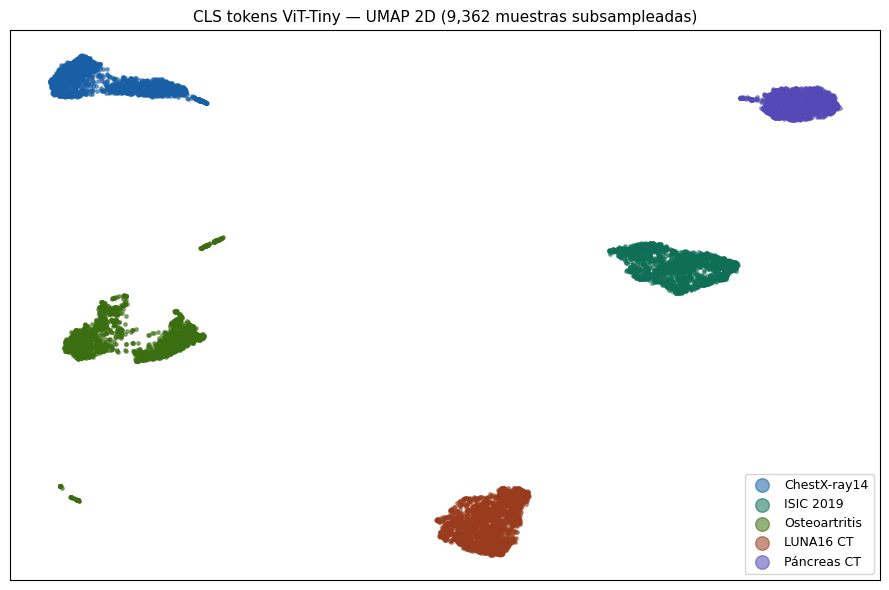

Guardado: figures/embeddings_2d_umap.png


In [21]:
import umap
import matplotlib.pyplot as plt
import plotly.express as px

EXPERT_NAMES = ['ChestX-ray14', 'ISIC 2019', 'Osteoartritis', 'LUNA16 CT', 'Páncreas CT']
COLORES      = ['#185FA5', '#0F6E56', '#3B6D11', '#993C1D', '#534AB7']

# ── CORRECCIÓN #11: subsampling para evitar OOM ───────────────────
MAX_PER_EXPERT = 2000
rng_umap = np.random.default_rng(SEED + 1)
idx_sub  = []
for i in range(5):
    mask = np.where(E_train == i)[0]
    n    = min(MAX_PER_EXPERT, len(mask))
    idx_sub.append(rng_umap.choice(mask, n, replace=False))
idx_sub = np.concatenate(idx_sub)

Z_umap = Z_all_train[idx_sub]
E_umap = E_train[idx_sub]
print(f'UMAP sobre {len(Z_umap):,} muestras (máx {MAX_PER_EXPERT} por experto)')
print(f'Distribución: { {EXPERT_NAMES[i]: int(np.sum(E_umap==i)) for i in range(5)} }')

# ── UMAP 2D ───────────────────────────────────────────────────────
print('\nCalculando UMAP 2D...')
reducer_2d = umap.UMAP(n_components=2, n_neighbors=30, metric='cosine', random_state=SEED)
Z2 = reducer_2d.fit_transform(Z_umap)

fig, ax = plt.subplots(figsize=(9, 6))
for i, (nombre, color) in enumerate(zip(EXPERT_NAMES, COLORES)):
    mask = E_umap == i
    ax.scatter(Z2[mask, 0], Z2[mask, 1], c=color, label=nombre, alpha=0.55, s=6)
ax.set_title(f'CLS tokens ViT-Tiny — UMAP 2D ({len(Z_umap):,} muestras subsampleadas)', fontsize=11)
ax.legend(markerscale=4, fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig('figures/embeddings_2d_umap.png', dpi=150)
plt.show()
print('Guardado: figures/embeddings_2d_umap.png')


## ✅ Checklist FASE 0

| Archivo | Descripción | d=192? |
|---------|-------------|--------|
| `embeddings/chest_train_Z.npy` | CLS tokens ChestXray train | ☐ |
| `embeddings/chest_train_y.npy` | Labels multilabel [N, 14] train | ☐ |
| `embeddings/chest_val_Z.npy`   | CLS tokens ChestXray val   | ☐ |
| `embeddings/chest_val_y.npy`   | Labels multilabel [N, 14] val   | ☐ |
| `embeddings/isic_train_Z.npy`  | CLS tokens ISIC train      | ☐ |
| `embeddings/isic_train_y.npy`  | Labels int [N] train (9 clases) | ☐ |
| `embeddings/isic_val_Z.npy`    | CLS tokens ISIC val        | ☐ |
| `embeddings/isic_val_y.npy`    | Labels int [N] val         | ☐ |
| `embeddings/osteo_train_Z.npy` | CLS tokens Osteo train     | ☐ |
| `embeddings/osteo_train_y.npy` | Labels int [N] train (5 clases KL) | ☐ |
| `embeddings/osteo_val_Z.npy`   | CLS tokens Osteo val       | ☐ |
| `embeddings/osteo_val_y.npy`   | Labels int [N] val         | ☐ |
| `embeddings/luna_train_Z.npy`  | CLS tokens LUNA16 train    | ☐ |
| `embeddings/luna_train_y.npy`  | Labels int [N] train (0/1) | ☐ |
| `embeddings/luna_val_Z.npy`    | CLS tokens LUNA16 val      | ☐ |
| `embeddings/luna_val_y.npy`    | Labels int [N] val         | ☐ |
| `panc/panc_train_Z.npy`        | Páncreas train Z (ya existía) | ✓ |
| `panc/panc_train_y.npy`        | Páncreas train y (ya existía) | ✓ |
| `panc/panc_val_Z.npy`          | Páncreas val Z (ya existía)   | ✓ |
| `panc/panc_val_y.npy`          | Páncreas val y (ya existía)   | ✓ |
| `embeddings/all_train_Z.npy`        | Z combinado train (5 datasets) | ☐ |
| `embeddings/all_train_expert_y.npy` | Expert labels train (0–4)      | ☐ |
| `embeddings/all_val_Z.npy`          | Z combinado val (5 datasets)   | ☐ |
| `embeddings/all_val_expert_y.npy`   | Expert labels val (0–4)        | ☐ |
| `figures/embeddings_2d_umap.png`    | UMAP 2D para el reporte        | ☐ |
| `figures/embeddings_3d_umap.html`   | UMAP 3D interactivo            | ☐ |

**Todos los embeddings deben tener `shape[1] == 192` (d_model ViT-Tiny).**  
**La detección 2D/3D es por `rank` del tensor — sin metadatos. ✓**  
**El NB-04 (Router) consume `all_train/val_Z.npy` + `all_train/val_expert_y.npy`. ✓**
